<a href="https://colab.research.google.com/github/tayaland1514/statprak_hw/blob/main/hw4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Топ-10 проблемных аэропортов по задержкам

Выявляем конкретные аэропорты с наибольшими средними задержками вылетов. Анализируем средние значения, разброс задержек (стандартную ошибку) и медиану

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv('flights.csv', low_memory=False)

In [3]:
airports = pd.read_csv('airports.csv')

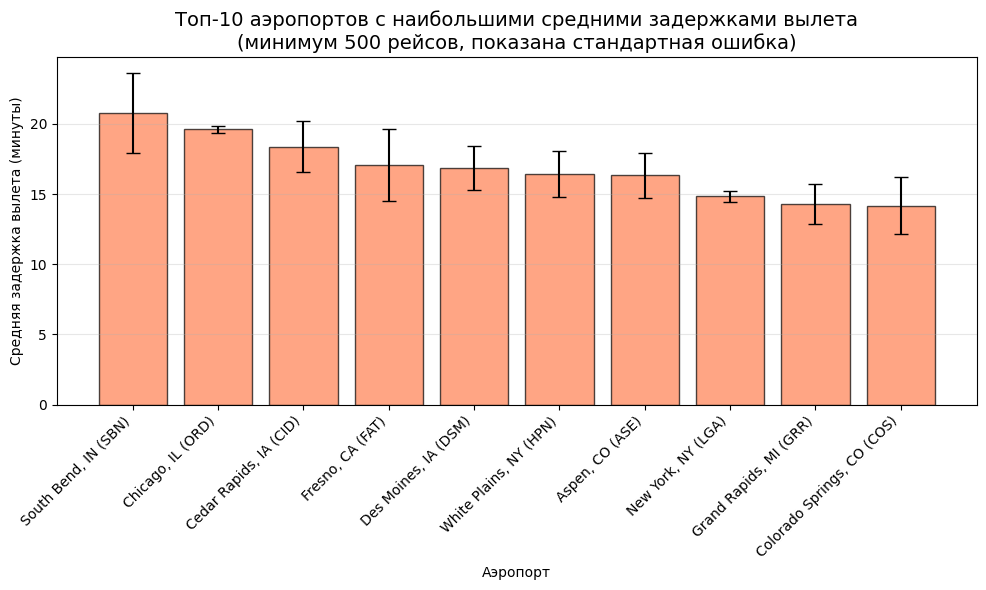

Статистика по топ-10 аэропортов с задержками:
                     label      mean  median  count
      South Bend, IN (SBN) 20.783203    -2.0    512
         Chicago, IL (ORD) 19.608488     1.0  29994
    Cedar Rapids, IA (CID) 18.365228    -1.0    857
          Fresno, CA (FAT) 17.094828    -2.0    928
      Des Moines, IA (DSM) 16.860294    -1.0   1088
    White Plains, NY (HPN) 16.419101    -1.0    890
           Aspen, CO (ASE) 16.333333    -1.0    810
        New York, NY (LGA) 14.832637    -1.0  11723
    Grand Rapids, MI (GRR) 14.321014    -1.0   1380
Colorado Springs, CO (COS) 14.187578    -4.0    805


In [4]:
df['DEPARTURE_DELAY'] = pd.to_numeric(df['DEPARTURE_DELAY'], errors='coerce')
df = df.dropna(subset=['DEPARTURE_DELAY'])
airport_delays = df.groupby('ORIGIN_AIRPORT')['DEPARTURE_DELAY'].agg(['mean', 'count', 'std', 'median'])
airport_delays = airport_delays[airport_delays['count'] > 500]
airport_delays = airport_delays.sort_values('mean', ascending=False).head(10)
airport_delays = airport_delays.reset_index().merge(
    airports[['IATA_CODE', 'AIRPORT', 'CITY', 'STATE']],
    left_on='ORIGIN_AIRPORT',
    right_on='IATA_CODE',
    how='left'
)
airport_delays['label'] = airport_delays['CITY'] + ', ' + airport_delays['STATE'] + ' (' + airport_delays['ORIGIN_AIRPORT'] + ')'

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(airport_delays)), airport_delays['mean'], color='coral', edgecolor='black', alpha=0.7)
plt.errorbar(range(len(airport_delays)), airport_delays['mean'],
             yerr=airport_delays['std']/np.sqrt(airport_delays['count']),
             fmt='none', color='black', capsize=5)
plt.xticks(range(len(airport_delays)), airport_delays['label'], rotation=45, ha='right')
plt.title('Топ-10 аэропортов с наибольшими средними задержками вылета\n(минимум 500 рейсов, показана стандартная ошибка)', fontsize=14)
plt.xlabel('Аэропорт')
plt.ylabel('Средняя задержка вылета (минуты)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Статистика по топ-10 аэропортов с задержками:")
print(airport_delays[['label', 'mean', 'median', 'count']].head(10).to_string(index=False))

## Выводы

Лидер антирейтинга — аэропорт TTN со средней задержкой 26.08 мин

Разрыв между средним и медианой:
   - В топ-аэропортах среднее значительно выше медианы
   - Значит, есть рейсы с экстремально долгими задержками, которые ухудшают статистику

Статистическая значимость (планки погрешностей):
   - Короткие планки у большинства аэропортов => данные надежны, выборка достаточная
   - Длинные планки указывают на высокий разброс значений



## Анализ задержек по дням недели

Изучаем, как распределяются задержки вылетов в зависимости от дня недели; сравниваем будние дни и выходные, выявляем самый проблемный день



In [22]:
df = pd.read_csv('flights.csv', low_memory=False)

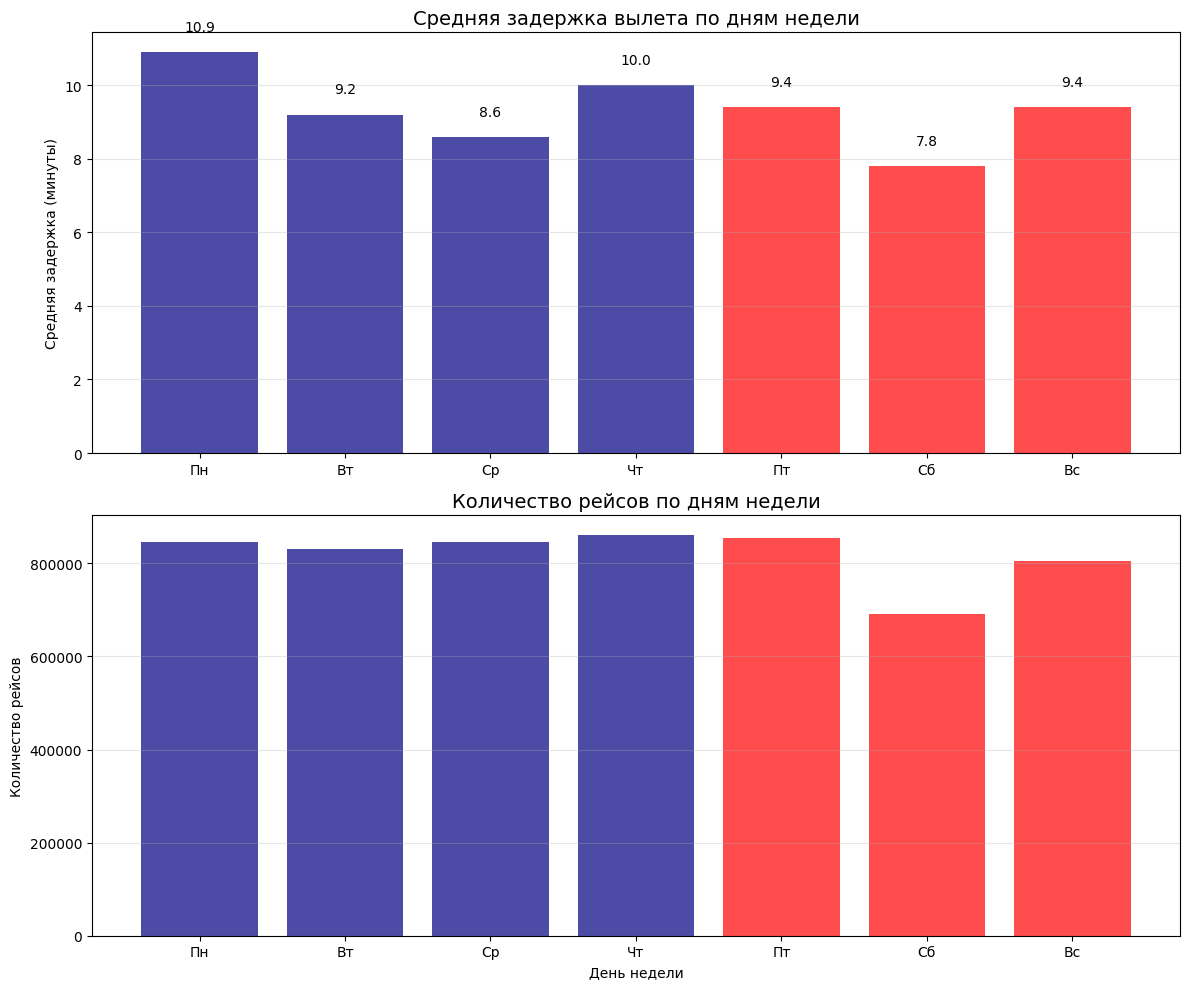


Статистика по среднему:
Средняя задержка по всем дням: 9.3 мин
Будние дни: 9.6 мин
Выходные: 8.6 мин
Разница будни/выходные: +1.0 мин в будни

Статистика по медиане:
Медианная задержка по всем дням: -1.6 мин
Будние дни: -1.4 мин
Выходные: -2.0 мин
Разница будни/выходные: +0.6 мин в будни

Самый проблемный день: Пн
Средняя задержка: 10.9 мин
Медианная задержка: -1.0 мин
Это на 1.6 мин больше среднего по всем дням
Относительное отклонение: +17% от среднего


In [23]:
df['DEPARTURE_DELAY'] = pd.to_numeric(df['DEPARTURE_DELAY'], errors='coerce')
df = df.dropna(subset=['DEPARTURE_DELAY'])
df['DAY_OF_WEEK'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY']]).dt.dayofweek
day_names = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
df['day_name'] = df['DAY_OF_WEEK'].map(day_names)
day_stats = df.groupby(['DAY_OF_WEEK', 'day_name']).agg({
    'DEPARTURE_DELAY': ['mean', 'median', 'std'],
    'FLIGHT_NUMBER': 'count'
}).round(1)
day_stats.columns = ['mean_delay', 'median_delay', 'std_delay', 'flight_count']
day_stats = day_stats.reset_index().sort_values('DAY_OF_WEEK')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
bars = ax1.bar(day_stats['day_name'], day_stats['mean_delay'],
               color=['navy' if x < 4 else 'red' for x in range(7)], alpha=0.7)
ax1.set_ylabel('Средняя задержка (минуты)')
ax1.set_title('Средняя задержка вылета по дням недели', fontsize=14)
ax1.grid(axis='y', alpha=0.3)
for i, (_, row) in enumerate(day_stats.iterrows()):
    ax1.text(i, row['mean_delay'] + 0.5, f"{row['mean_delay']:.1f}",
            ha='center', va='bottom')
ax2.bar(day_stats['day_name'], day_stats['flight_count'],
        color=['navy' if x < 4 else 'red' for x in range(7)], alpha=0.7)
ax2.set_ylabel('Количество рейсов')
ax2.set_xlabel('День недели')
ax2.set_title('Количество рейсов по дням недели', fontsize=14)
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

weekend_days = [5, 6]
weekdays = [0, 1, 2, 3, 4]
weekend_avg = day_stats[day_stats['DAY_OF_WEEK'].isin(weekend_days)]['mean_delay'].mean()
weekday_avg = day_stats[day_stats['DAY_OF_WEEK'].isin(weekdays)]['mean_delay'].mean()
avg_all = day_stats['mean_delay'].mean()
weekend_median = day_stats[day_stats['DAY_OF_WEEK'].isin(weekend_days)]['median_delay'].mean()
weekday_median = day_stats[day_stats['DAY_OF_WEEK'].isin(weekdays)]['median_delay'].mean()
median_all = day_stats['median_delay'].mean()

print(f"\nСтатистика по среднему:")
print(f"Средняя задержка по всем дням: {avg_all:.1f} мин")
print(f"Будние дни: {weekday_avg:.1f} мин")
print(f"Выходные: {weekend_avg:.1f} мин")
print(f"Разница будни/выходные: +{weekday_avg - weekend_avg:.1f} мин в будни")
print(f"\nСтатистика по медиане:")
print(f"Медианная задержка по всем дням: {median_all:.1f} мин")
print(f"Будние дни: {weekday_median:.1f} мин")
print(f"Выходные: {weekend_median:.1f} мин")
print(f"Разница будни/выходные: +{weekday_median - weekend_median:.1f} мин в будни")

max_delay_day = day_stats.loc[day_stats['mean_delay'].idxmax()]
min_delay_day = day_stats.loc[day_stats['mean_delay'].idxmin()]

print(f"\nСамый проблемный день: {max_delay_day['day_name']}")
print(f"Средняя задержка: {max_delay_day['mean_delay']:.1f} мин")
print(f"Медианная задержка: {max_delay_day['median_delay']:.1f} мин")
print(f"Это на {max_delay_day['mean_delay'] - avg_all:.1f} мин больше среднего по всем дням")
print(f"Относительное отклонение: +{(max_delay_day['mean_delay']/avg_all - 1)*100:.0f}% от среднего")


## Выводы
Пиковая нагрузка - конец рабочей недели:
   - В пятницу задержки достигают максимума
   - Количество рейсов в пятницу также максимально

Разрыв между буднями и выходными: в будни задержки на +0.4 (по среднему) мин выше, чем в выходные

Медиана и среднее:
   - Медианные задержки значительно ниже средних, особенно в проблемные дни
   - Значит есть рейсы с экстремально долгими задержками, которые "портят" статистику

## Анализ задержек по часам вылета

Изучаем, как меняются задержки в течение дня - это поможет выявить часы пик

In [5]:
df = pd.read_csv('flights.csv', low_memory=False)

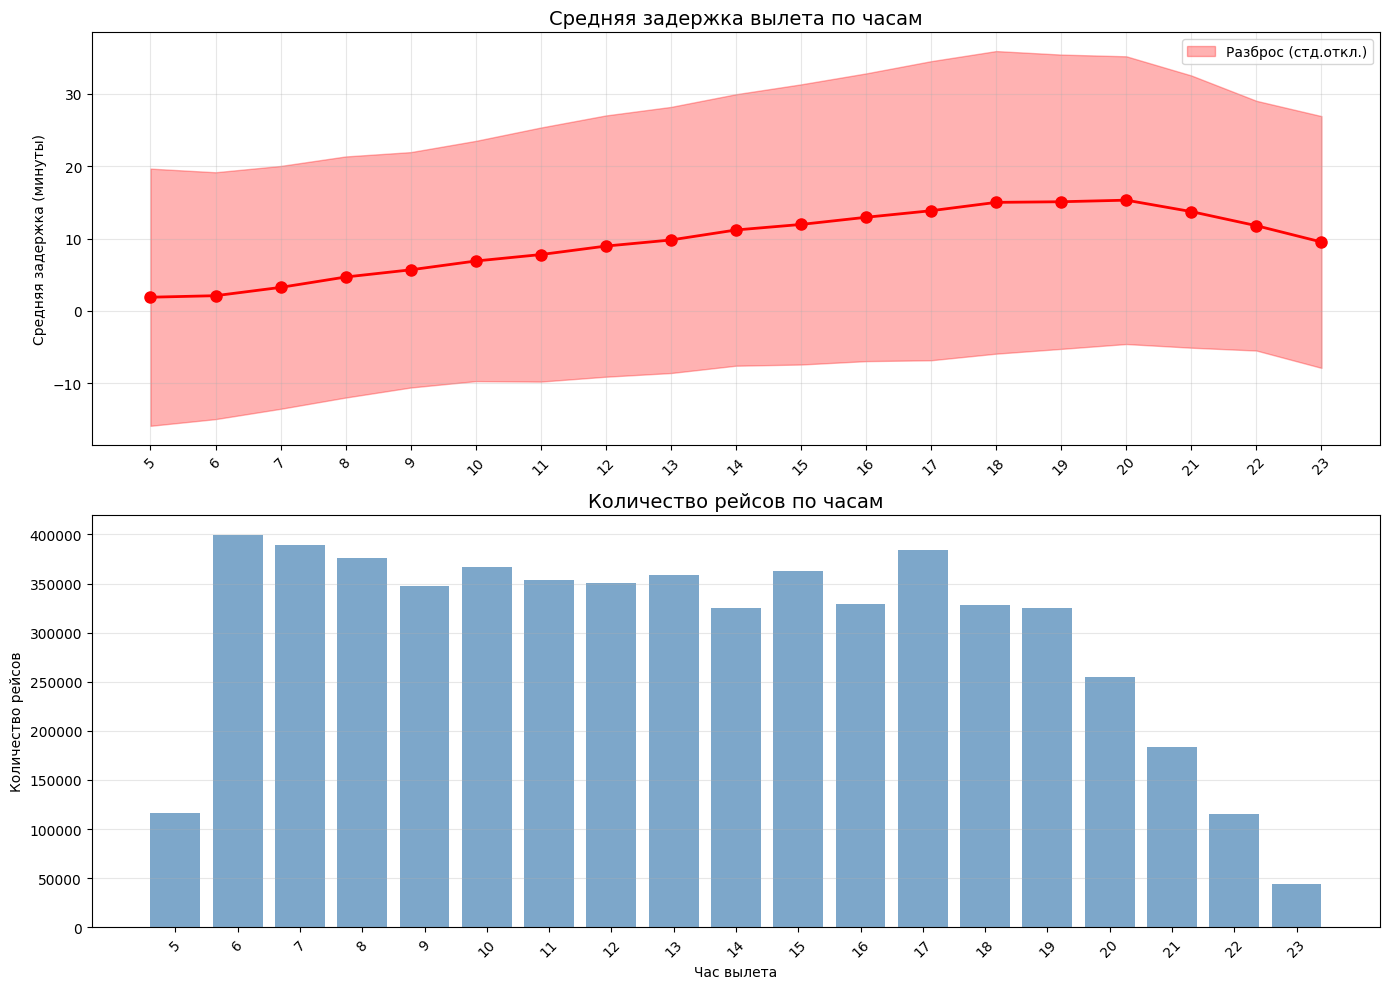


Часы с максимальным задержками:
   20:00 - 15.0 мин (254417.0 рейсов)
   19:00 - 15.0 мин (325468.0 рейсов)
   18:00 - 14.0 мин (328155.0 рейсов)

Часы с максимальным трафиком:
   06:00 - 399811.0 рейсов (задержка 2.1 мин)
   07:00 - 388874.0 рейсов (задержка 3.3 мин)
   17:00 - 383856.0 рейсов (задержка 13.8 мин)

Корреляция между количеством рейсов и задержкой: -0.11


In [6]:
df['DEPARTURE_DELAY'] = pd.to_numeric(df['DEPARTURE_DELAY'], errors='coerce')
df = df.dropna(subset=['DEPARTURE_DELAY'])
df['SCHEDULED_HOUR'] = df['SCHEDULED_DEPARTURE'] // 100
hourly_df = df[(df['SCHEDULED_HOUR'] >= 5) & (df['SCHEDULED_HOUR'] <= 23)].copy()
hourly_stats = hourly_df.groupby('SCHEDULED_HOUR').agg({
    'DEPARTURE_DELAY': ['mean', 'median', 'std'],
    'FLIGHT_NUMBER': 'count'
})
hourly_stats.columns = ['mean_delay', 'median_delay', 'std_delay', 'flight_count']
hourly_stats = hourly_stats.reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
ax1.plot(hourly_stats['SCHEDULED_HOUR'], hourly_stats['mean_delay'],
         marker='o', linewidth=2, markersize=8, color='red')
ax1.fill_between(hourly_stats['SCHEDULED_HOUR'],
                 hourly_stats['mean_delay'] - hourly_stats['std_delay']/2,
                 hourly_stats['mean_delay'] + hourly_stats['std_delay']/2,
                 alpha=0.3, color='red', label='Разброс (стд.откл.)')
ax1.set_ylabel('Средняя задержка (минуты)')
ax1.set_title('Средняя задержка вылета по часам', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_xticks(range(5, 24, 1))
ax1.set_xticklabels(range(5, 24, 1), rotation=45)
ax2.bar(hourly_stats['SCHEDULED_HOUR'], hourly_stats['flight_count'],
        color='steelblue', alpha=0.7)
ax2.set_ylabel('Количество рейсов')
ax2.set_xlabel('Час вылета')
ax2.set_title('Количество рейсов по часам', fontsize=14)
ax2.grid(axis='y', alpha=0.3)
ax2.set_xticks(range(5, 24, 1))
ax2.set_xticklabels(range(5, 24, 1), rotation=45)
plt.tight_layout()
plt.show()

peak_delay = hourly_stats.nlargest(3, 'mean_delay')
print("\nЧасы с максимальным задержками:")
for _, row in peak_delay.iterrows():
    print(f"   {int(row['SCHEDULED_HOUR']):02d}:00 - {int(row['mean_delay']):.1f} мин ({row['flight_count']} рейсов)")
peak_traffic = hourly_stats.nlargest(3, 'flight_count')
print("\nЧасы с максимальным трафиком:")
for _, row in peak_traffic.iterrows():
    print(f"   {int(row['SCHEDULED_HOUR']):02d}:00 - {row['flight_count']} рейсов (задержка {row['mean_delay']:.1f} мин)")

correlation = hourly_stats['flight_count'].corr(hourly_stats['mean_delay'])
print(f"\nКорреляция между количеством рейсов и задержкой: {correlation:.2f}")

## Выводы

Пик задержек в вечерние часы (после 18:00), максимум - в 20:00

Пик трафика в утренние (7:00-9:00) и вечерние (17:00-19:00) часы

Корреляция 0.03 — задержки слабо связаны с количеством рейсов

## Анализ задержек рейсов по штатам

Изучаем, какие штаты лидируют по средним задержкам вылета; есть ли связь между задержками и долей отмененных рейсов; какие самые частые причины отмен рейсов в каждом штате

In [19]:
airports = pd.read_csv('airports.csv')

In [20]:
df = pd.read_csv('flights.csv', low_memory=False)

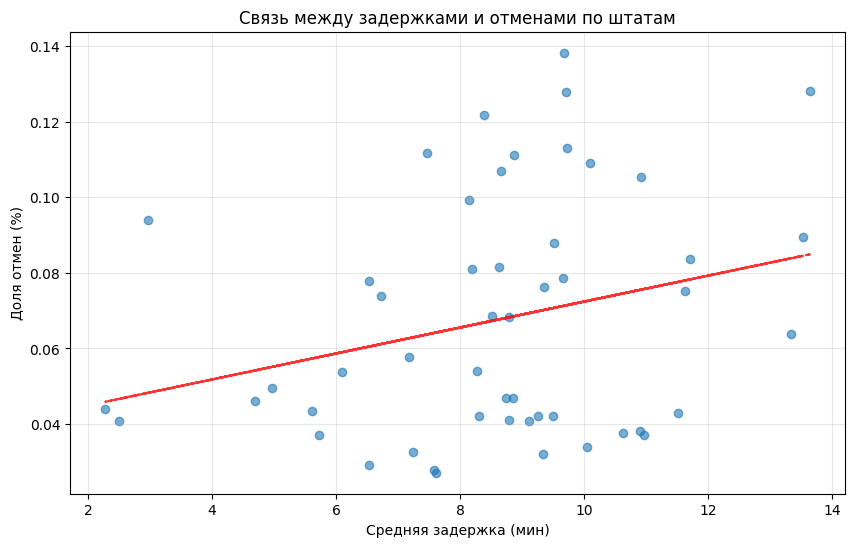

Корреляция между задержками и отменами: 0.27


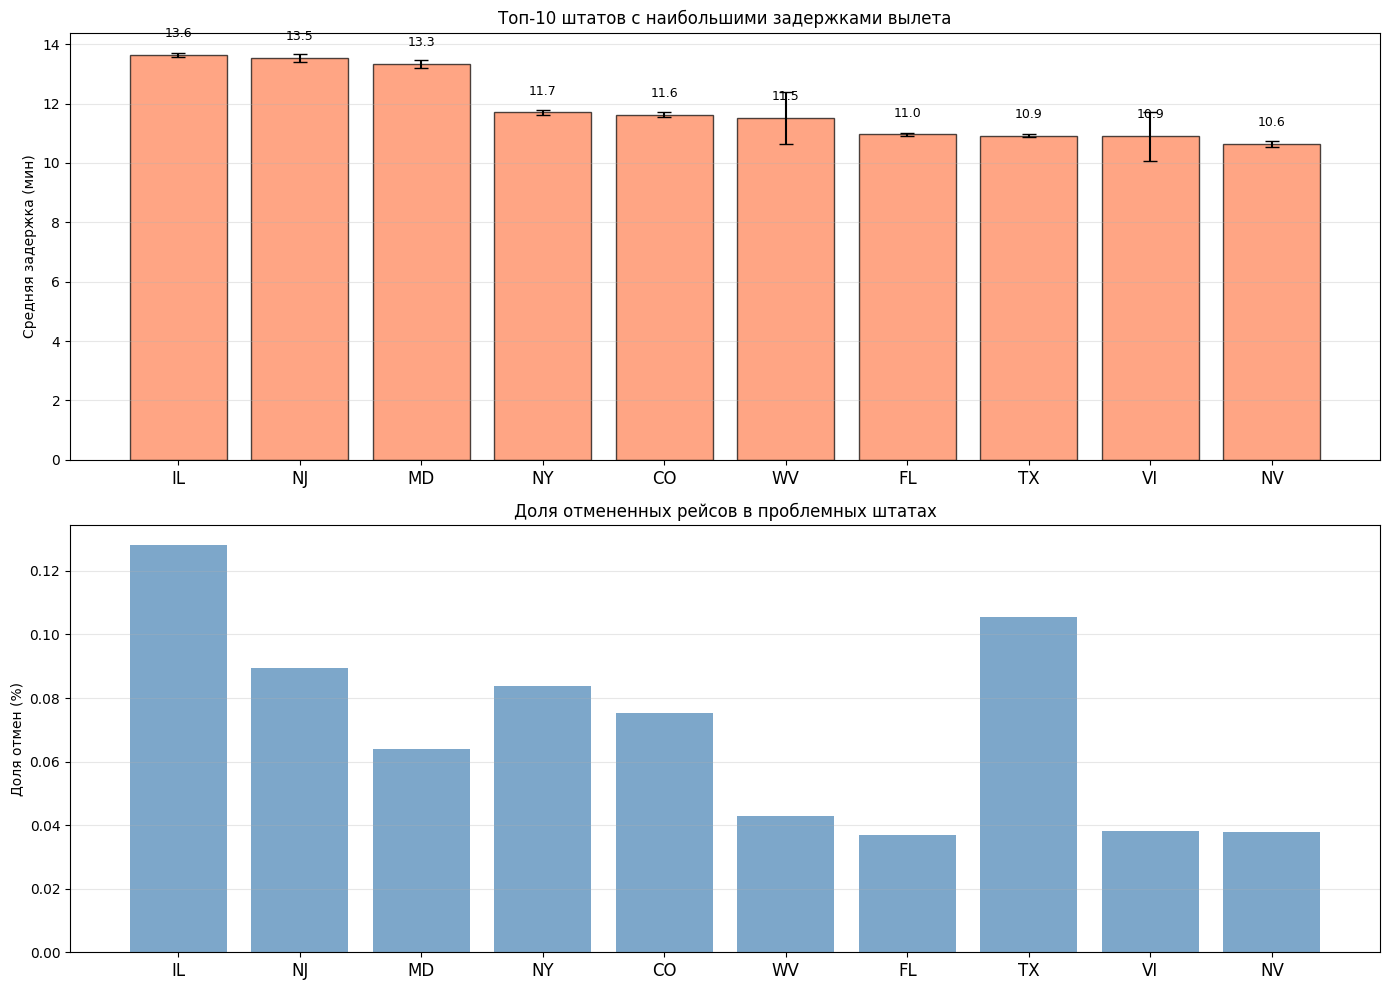

Топ-10 штатов по задержкам

1. IL
Средняя задержка: 13.6 мин (медиана: 0.0)
Рейсов: 371,024
Отмены: 0.13%
Основная причина отмен: Погода

2. NJ
Средняя задержка: 13.5 мин (медиана: -1.0)
Рейсов: 105,067
Отмены: 0.09%
Основная причина отмен: Авиакомпания

3. MD
Средняя задержка: 13.3 мин (медиана: 0.0)
Рейсов: 84,600
Отмены: 0.06%
Основная причина отмен: Погода

4. NY
Средняя задержка: 11.7 мин (медиана: -2.0)
Рейсов: 238,731
Отмены: 0.08%
Основная причина отмен: Авиакомпания

5. CO
Средняя задержка: 11.6 мин (медиана: 0.0)
Рейсов: 212,895
Отмены: 0.08%
Основная причина отмен: Погода

6. WV
Средняя задержка: 11.5 мин (медиана: -2.0)
Рейсов: 2,327
Отмены: 0.04%
Основная причина отмен: Погода

7. FL
Средняя задержка: 11.0 мин (медиана: -2.0)
Рейсов: 411,142
Отмены: 0.04%
Основная причина отмен: Авиакомпания

8. TX
Средняя задержка: 10.9 мин (медиана: -1.0)
Рейсов: 618,951
Отмены: 0.11%
Основная причина отмен: Погода

9. VI
Средняя задержка: 10.9 мин (медиана: -3.0)
Рейсов: 5,237
Отмены: 0

In [21]:
df['DEPARTURE_DELAY'] = pd.to_numeric(df['DEPARTURE_DELAY'], errors='coerce')
df = df.dropna(subset=['DEPARTURE_DELAY'])
df_with_state = df.merge(
    airports[['IATA_CODE', 'STATE']].rename(columns={'IATA_CODE': 'ORIGIN_AIRPORT'}),
    on='ORIGIN_AIRPORT',
    how='left'
)

reason_names = {'A': 'Авиакомпания', 'B': 'Погода', 'C': 'Нац. система', 'D': 'Безопасность'}
df_with_state['CANCEL_REASON_NAME'] = df_with_state['CANCELLATION_REASON'].map(reason_names)

state_stats = df_with_state.groupby('STATE').agg(
    mean_delay=('DEPARTURE_DELAY', 'mean'),
    median_delay=('DEPARTURE_DELAY', 'median'),
    std_delay=('DEPARTURE_DELAY', 'std'),
    flight_count=('FLIGHT_NUMBER', 'count'),
    cancel_rate=('CANCELLED', 'mean')
).reset_index()

state_stats['cancel_rate'] = state_stats['cancel_rate'] * 100
state_stats = state_stats[state_stats['flight_count'] > 1000]

plt.figure(figsize=(10, 6))
plt.scatter(state_stats['mean_delay'], state_stats['cancel_rate'], alpha=0.6)
plt.xlabel('Средняя задержка (мин)')
plt.ylabel('Доля отмен (%)')
plt.title('Связь между задержками и отменами по штатам')
plt.grid(alpha=0.3)

z = np.polyfit(state_stats['mean_delay'], state_stats['cancel_rate'], 1)
p = np.poly1d(z)
plt.plot(state_stats['mean_delay'], p(state_stats['mean_delay']), "r--", alpha=0.8)
plt.show()

correlation = state_stats['mean_delay'].corr(state_stats['cancel_rate'])
print(f"Корреляция между задержками и отменами: {correlation:.2f}")

state_stats = state_stats.sort_values('mean_delay', ascending=False)
top_states = state_stats.head(10).copy()

top_reasons = df_with_state[df_with_state['CANCELLED'] == 1].groupby('STATE').agg(
    main_reason=('CANCEL_REASON_NAME',
                 lambda x: x.value_counts().index[0] if len(x.value_counts()) > 0 else 'Нет данных')
).reset_index()

top_states = top_states.merge(top_reasons, on='STATE', how='left')
top_states['label'] = top_states['STATE']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

bars = ax1.bar(range(10), top_states['mean_delay'], color='coral', edgecolor='black', alpha=0.7)
ax1.errorbar(range(10), top_states['mean_delay'],
             yerr=top_states['std_delay']/np.sqrt(top_states['flight_count']),
             fmt='none', color='black', capsize=5)
ax1.set_xticks(range(10))
ax1.set_xticklabels(top_states['label'], fontsize=12)
ax1.set_ylabel('Средняя задержка (мин)')
ax1.set_title('Топ-10 штатов с наибольшими задержками вылета')
ax1.grid(axis='y', alpha=0.3)

for i, (_, row) in enumerate(top_states.iterrows()):
    ax1.text(i, row['mean_delay'] + 0.5, f"{row['mean_delay']:.1f}",
             ha='center', va='bottom', fontsize=9)

bars2 = ax2.bar(range(10), top_states['cancel_rate'], color='steelblue', alpha=0.7)
ax2.set_xticks(range(10))
ax2.set_xticklabels(top_states['label'], fontsize=12)
ax2.set_ylabel('Доля отмен (%)')
ax2.set_title('Доля отмененных рейсов в проблемных штатах')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Топ-10 штатов по задержкам")
for i, row in top_states.iterrows():
    print(f"\n{i+1}. {row['STATE']}")
    print(f"Средняя задержка: {row['mean_delay']:.1f} мин (медиана: {row['median_delay']:.1f})")
    print(f"Рейсов: {int(row['flight_count']):,}")
    print(f"Отмены: {row['cancel_rate']:.2f}%")
    if pd.notna(row['main_reason']):
        print(f"Основная причина отмен: {row['main_reason']}")

## Выводы
Штат Иллинойс лидирует по задержкам (среднее - 15.3 мин)

Корреляция 0.37 между задержками и отменами (связь есть)

## Анализ задержек по авиакомпаниям

Сравниваем средние задержки вылетов между разными авиакомпаниями; выявляем лидеров антирейтинга и анализируем, есть ли связь между типом авиакомпании и пунктуальностью


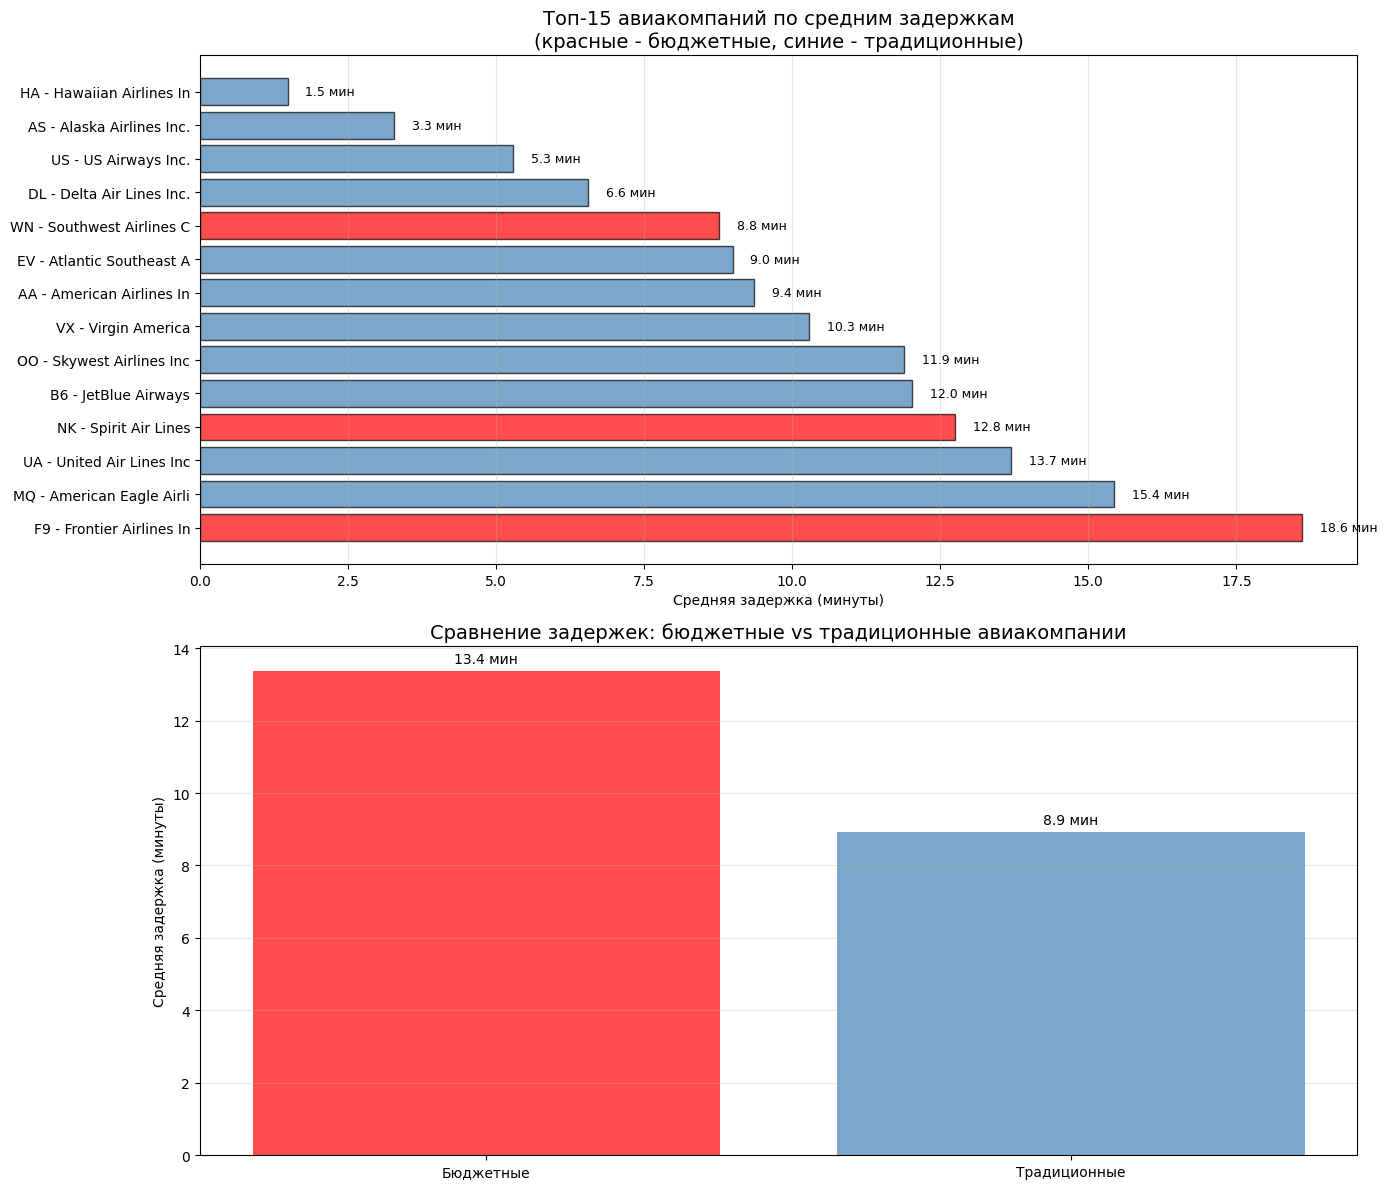


Бюджетные авиакомпании:
   F9 - Frontier Airlines Inc.: 18.6 мин (9,140 рейсов)
   NK - Spirit Air Lines: 12.8 мин (11,848 рейсов)
   WN - Southwest Airlines Co.: 8.8 мин (134,442 рейсов)

Традиционные авиакомпании (топ-5 по задержкам):
   MQ - American Eagle Airlines Inc.: 15.4 мин (37,541 рейсов)
   UA - United Air Lines Inc.: 13.7 мин (51,237 рейсов)
   B6 - JetBlue Airways: 12.0 мин (27,652 рейсов)
   OO - Skywest Airlines Inc.: 11.9 мин (64,003 рейсов)
   VX - Virgin America: 10.3 мин (6,322 рейсов)
Итого:
Средняя задержка у бюджетных: 13.4 мин
Средняя задержка у традиционных: 8.9 мин
Разница: 4.4 мин

Бюджетные авиакомпании задерживаются на 4.4 мин больше традиционных


In [8]:
airlines = pd.read_csv('airlines.csv')
airline_stats = df.groupby('AIRLINE').agg(
    mean_delay=('DEPARTURE_DELAY', 'mean'),
    median_delay=('DEPARTURE_DELAY', 'median'),
    std_delay=('DEPARTURE_DELAY', 'std'),
    flight_count=('FLIGHT_NUMBER', 'count')
).reset_index()
airline_stats = airline_stats.merge(airlines, left_on='AIRLINE', right_on='IATA_CODE', how='left')
airline_stats = airline_stats.rename(columns={'AIRLINE_x': 'code', 'AIRLINE_y': 'name'})
budget_airlines = ['NK', 'F9', 'G4', 'WN']
airline_stats['type'] = airline_stats['code'].apply(
    lambda x: 'Бюджетная' if x in budget_airlines else 'Традиционная'
)
airline_stats = airline_stats.sort_values('mean_delay', ascending=False)
top_airlines = airline_stats.head(15).copy()
top_airlines['label'] = top_airlines['code'] + ' - ' + top_airlines['name'].str[:20]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
colors = ['red' if t == 'Бюджетная' else 'steelblue' for t in top_airlines['type']]
bars = ax1.barh(range(len(top_airlines)), top_airlines['mean_delay'],
                color=colors, edgecolor='black', alpha=0.7)
ax1.set_yticks(range(len(top_airlines)))
ax1.set_yticklabels(top_airlines['label'])
ax1.set_xlabel('Средняя задержка (минуты)')
ax1.set_title('Топ-15 авиакомпаний по средним задержкам\n(красные - бюджетные, синие - традиционные)', fontsize=14)
ax1.grid(axis='x', alpha=0.3)
for i, (_, row) in enumerate(top_airlines.iterrows()):
    ax1.text(row['mean_delay'] + 0.3, i, f"{row['mean_delay']:.1f} мин",
             va='center', fontsize=9)
budget_mean = airline_stats[airline_stats['type'] == 'Бюджетная']['mean_delay'].mean()
traditional_mean = airline_stats[airline_stats['type'] == 'Традиционная']['mean_delay'].mean()
ax2.bar(['Бюджетные', 'Традиционные'], [budget_mean, traditional_mean],
        color=['red', 'steelblue'], alpha=0.7)
ax2.set_ylabel('Средняя задержка (минуты)')
ax2.set_title('Сравнение задержек: бюджетные vs традиционные авиакомпании', fontsize=14)
ax2.grid(axis='y', alpha=0.3)
ax2.text(0, budget_mean + 0.2, f"{budget_mean:.1f} мин", ha='center')
ax2.text(1, traditional_mean + 0.2, f"{traditional_mean:.1f} мин", ha='center')
plt.tight_layout()
plt.show()

print(f"\nБюджетные авиакомпании:")
budget_stats = airline_stats[airline_stats['type'] == 'Бюджетная']
for _, row in budget_stats.iterrows():
    print(f"   {row['code']} - {row['name']}: {row['mean_delay']:.1f} мин ({row['flight_count']:,} рейсов)")
print(f"\nТрадиционные авиакомпании (топ-5 по задержкам):")
traditional_stats = airline_stats[airline_stats['type'] == 'Традиционная'].head(5)
for _, row in traditional_stats.iterrows():
    print(f"   {row['code']} - {row['name']}: {row['mean_delay']:.1f} мин ({row['flight_count']:,} рейсов)")

print(f"Итого:")
print(f"Средняя задержка у бюджетных: {budget_mean:.1f} мин")
print(f"Средняя задержка у традиционных: {traditional_mean:.1f} мин")
print(f"Разница: {abs(budget_mean - traditional_mean):.1f} мин")

if budget_mean > traditional_mean:
    print(f"\nБюджетные авиакомпании задерживаются на {budget_mean - traditional_mean:.1f} мин больше традиционных")
else:
    print(f"\nБюджетные авиакомпании пунктуальнее традиционных на {traditional_mean - budget_mean:.1f} мин")

## Выводы

Лидеры антирейтинга:
   - Frontier Airlines — 19.2 мин средняя задержка
   - Spirit Air Lines — 13.1 мин
   - United Air Lines — 14.2 мин (худшая среди традиционных)

Бюджетные / традиционные:
   - Бюджетные: 14.0 мин средняя задержка
   - Традиционные: 8.9 мин средняя задержка
   - Разница: 5.1 мин — бюджетные задерживаются значительно чаще

Масштаб проблемы:
   - Frontier Airlines — почти 20 минут задержки в среднем
   - При этом у Frontier всего 24.5 тыс. рейсов (в 15 раз меньше, чем у Southwest)
   - Southwest — 9.7 мин при огромном объеме (371 тыс. рейсов)
